# SPARC-4 products
***

This notebook shows an example for viewing and accessing the SPARC4 data products.

* Eder Martioli, LNA 18 Apr 2024
* Fernando Falkenberg INPE 09 Oct 2025

In [2]:
from astropy.io import fits, ascii
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sparc4.product_plots as s4plt
import sparc4.pipeline_lib as s4pipelib

### Set paths to example files 
Below we set the paths to the files, which are sparc4-pipeline products.

In [4]:
path = '/media/fernando/KINGSTON/Doutorado/2025/reduced/'
date = '20250701'
object = 'V2400_Oph'
channel = '4'

In [5]:
db_example = f'{path}{date}/sparc4acs{channel}/{date}_sparc4acs{channel}_db.csv'
# Esse arquivo é uma tabela que contém informações de todas as imagens daquela noite, naquele canal, por exemplo, diretório, tempo de exposição, posição da lâmina, etc.

phot_lightcurve_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_{object}_POLAR_L4_S+N_lc.fits'
# Esse arquivo contém várias tabelas dentro dele, uma pra cada abertura em que os dados do objeto foram processados. Dentro de cada tabela, estão informações de cada uma das fontes detectadas pelo pipeline, para cada imagem daquele objeto, por exemplo, RA, Dec, magnitude (com seu erro), fwhm, etc.

polar_stack_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_Gain2_1.0_Conventional_2_{object}_POLAR_L4_stack.fits'
# Esse arquivo contém várias tabelas dentro dele, duas para cada abertura em que os dados do objeto foram processados (sendo uma para o feixe ordinário e a outra para o feixe extraordinário). Cada tabela contém uma linha para cada fonte identificada pelo pipeline. Para cada linha, existem informações como RA, Dec, magnitude (com seu erro), fwhm, etc. É uma versão do arquivo logo acima, só que para apenas uma imagem stack.

polar_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_Gain2_1.0_Conventional_2_{object}_POLAR_L4_polar.fits'
# Esse arquivo contém várias tabelas, uma pra cada abertura em que os dados do objeto foram processados. Dentro de cada tabela existe uma linha para cada fonte detectada pelo pipeline. Em cada linha estão os resultados da polarimetria para aquela fonte, por exemplo, x1, y1, x2, y2, mag, emag, Q, U, V, P, theta, fwhm, zero, ezero, k, chi2, rms... Além disso, também estão as contagens para cada posição de lâmina, para cada fonte, para cada imagem, com seus erros. É nesse arquivo que estão os dados importantes.

polar_time_series_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_{object}_POLAR_L4_ts.fits'
# Esse arquivo contém uma tabela com os dados da série temporal polarimétrica das fontes detectadas pelo pipeline, por exemplo, RA, Dec, x1, y1, x2, y2, mag, emag, Q, U, V, P, theta, fwhm, zero, ezero, k, chi2, rms... O resultado aqui é para cada conjunto de uma medida polarimétrica.

# DB product example
***
In this simple example, we just read the database created by the `sparc4-pipeline` and print it as a pandas table. It's an easy way to quickly access the log of observations.

In [7]:
db = ascii.read(db_example)
pd.DataFrame(np.array(db))

,FILE,DATE-OBS,EXPTIME,RA,DEC,OBJECT,OBSTYPE,INSTMODE,CHANNEL,VBIN,...,VCLKAMP,CCDSERN,PREAMP,READRATE,EMMODE,EMGAIN,WPPOS,WPSEL,CALW,ASEL
0,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:20.327000,0.8,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,1,L2,None,True
1,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:27.088000,0.8,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,2,L2,None,True
2,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:33.670000,0.8,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,3,L2,None,True
3,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:40.462000,0.8,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,4,L2,None,True
4,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:47.050000,0.8,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,5,L2,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T04:59:06.319000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,8,L4,None,True
302,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T04:59:48.861000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,9,L4,None,True
303,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T05:00:31.423000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,10,L4,None,True
304,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T05:01:14.001000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,11,L4,None,True


# POLAR products example
***
In this example we show how to work with the polarimetric products of SPARC4

We start by reading the science image FITS file and showing its information. 

In [10]:
hdul = fits.open(polar_stack_example)
hdul.info()

Filename: /media/fernando/KINGSTON/Doutorado/2025/reduced/20250701/sparc4acs4/20250701_s4c4_Gain2_1.0_Conventional_2_V2400_Oph_POLAR_L4_stack.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     157   (1024, 1024)   float64   
  1  CATALOG_POL_S_AP005    1 TableHDU        51   46R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  2  CATALOG_POL_N_AP005    1 TableHDU        51   46R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  3  CATALOG_POL_S_AP008    1 TableHDU        51   46R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  4  CATALOG_POL_N_AP008    1 TableHDU        51   46R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  5  CATALOG_POL_S_AP010    1 TableHDU        51   46R x 13C   [I11, D25.17

Then we plot the science frame using the `sparc4.product_plots` library

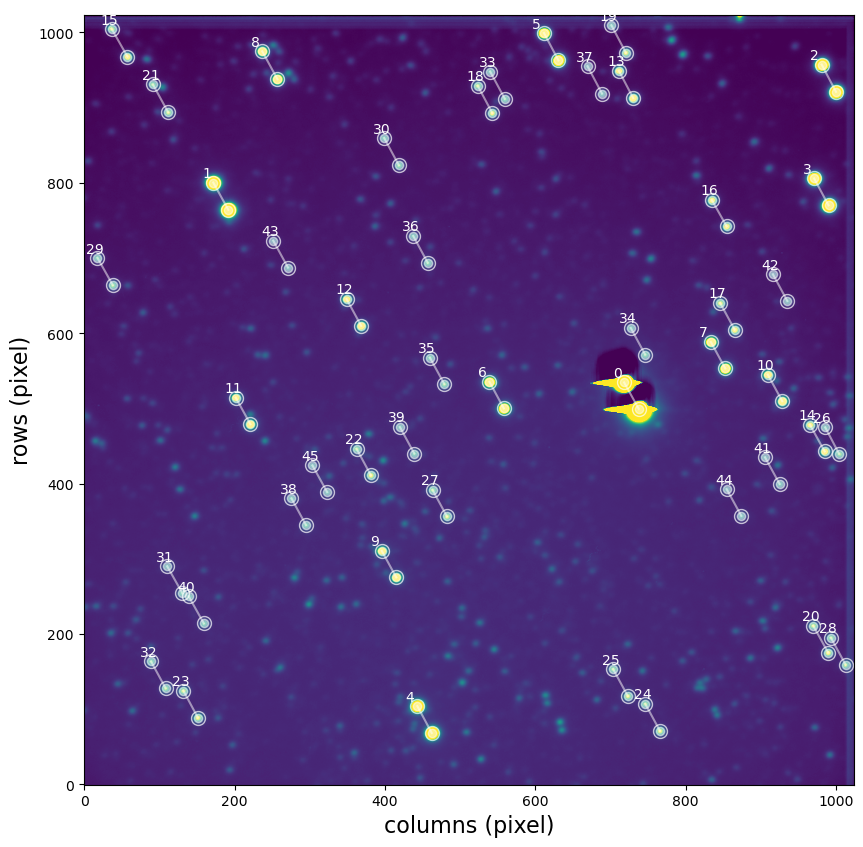

In [12]:
s4plt.plot_sci_polar_frame(polar_stack_example)

Now print one of the catalogs to see its contents

In [14]:
catalog = 'CATALOG_POL_N_AP010'
pd.DataFrame(hdul[catalog].data)

,SRCINDEX,RA,DEC,X,Y,FWHMX,FWHMY,MAG,EMAG,SKYMAG,ESKYMAG,APER,FLAG
0,0,258.124918,-24.248619,737.543831,499.361587,10.921346,10.921346,-12.114543,0.000363,-9.250013,0.001501,10,0
1,1,258.181225,-24.224378,191.690667,764.116717,8.367402,8.367402,-10.839036,0.000727,-9.137537,0.001430,10,0
2,2,258.098657,-24.208972,999.847916,920.927744,8.168942,8.168942,-10.439651,0.001175,-9.078892,0.002941,10,0
3,3,258.099459,-24.223093,989.923510,769.982419,8.124574,8.124574,-10.424482,0.001005,-9.116488,0.001881,10,0
4,4,258.152449,-24.288982,462.259484,68.288419,7.844676,7.844676,-10.276078,0.000965,-9.256480,0.000734,10,0
5,5,258.136508,-24.205424,630.727933,962.760525,8.143460,8.143460,-9.861753,0.001622,-9.118495,0.002247,10,0
6,6,258.143250,-24.248725,558.119461,499.986854,8.039839,8.039839,-9.621926,0.001530,-9.225167,0.000966,10,0
7,7,258.113202,-24.243476,852.585002,553.077547,8.094868,8.094868,-9.445462,0.001874,-9.207949,0.001330,10,0
8,8,258.174801,-24.208064,257.027252,937.786549,8.118994,8.118994,-9.360579,0.001923,-9.106656,0.001355,10,0
9,9,258.157591,-24.269790,415.086967,275.181375,7.979213,7.979213,-8.917376,0.002436,-9.252615,0.000687,10,0


Below we select the source with its index number assigned as the main target to be analyzed. Then we select other stars as comparisons for differential photometry. All indices are displayed in the image above.  

After selecting the stars we use the function `s4plt.plot_light_curve` to produce plots of the lightcurve data.

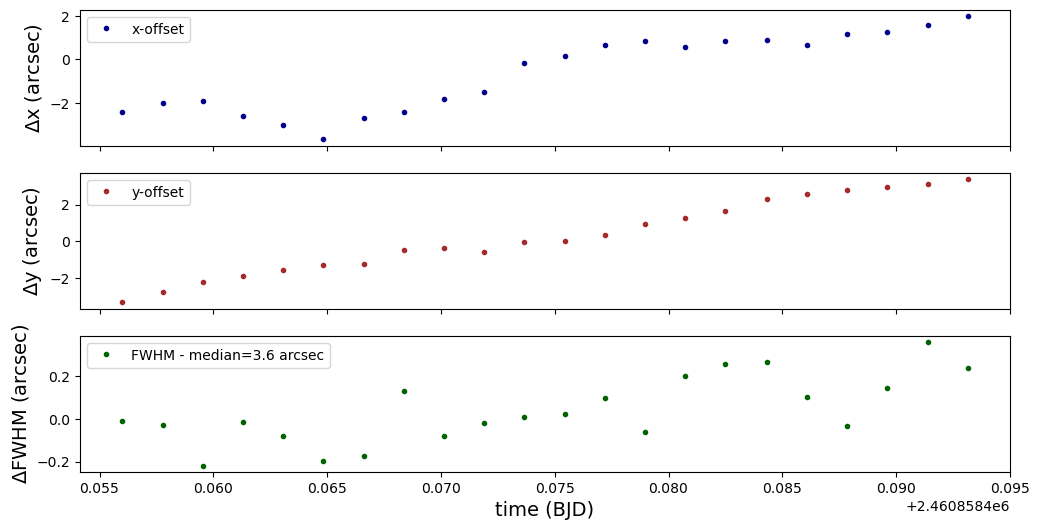

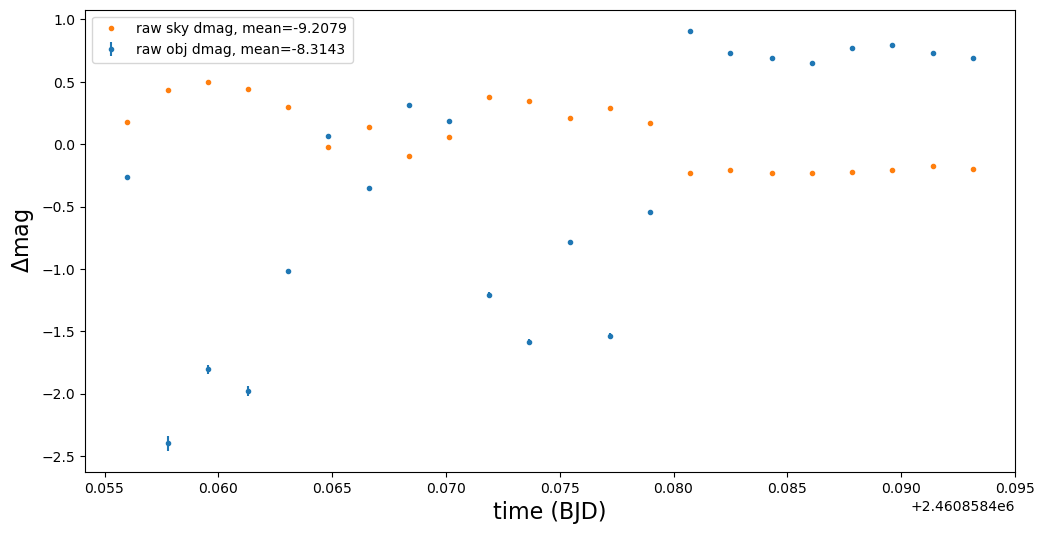

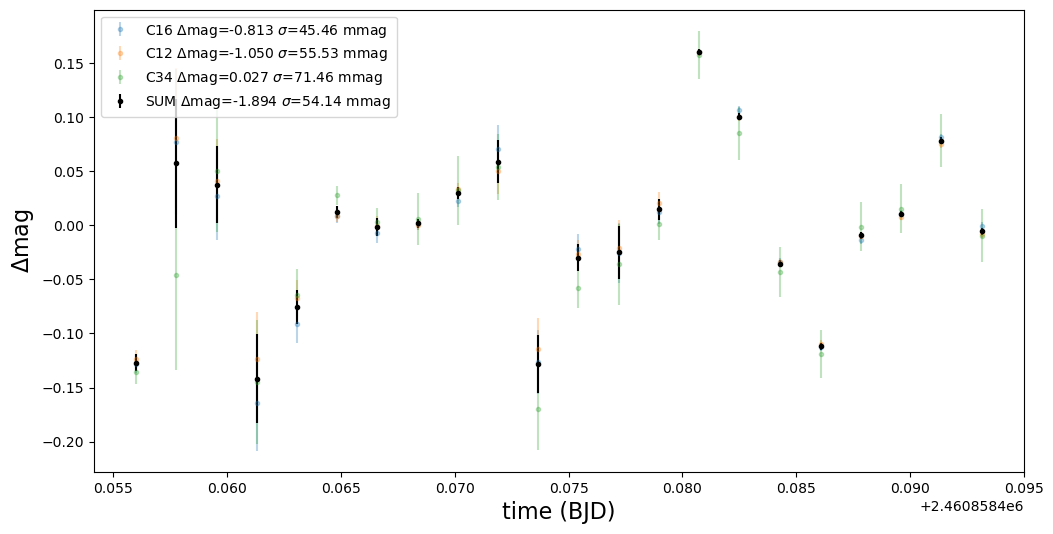

       TIME                x         ...       diffmagsum      
------------------ ----------------- ... ----------------------
2460858.4560015216 469.3519391031507 ...     -0.126928452856081
 2460858.457772584 470.6019391031507 ...    0.05729800236396798
 2460858.459537559 470.8519391031507 ...    0.03768712269389418
  2460858.46130287 468.8519391031507 ...   -0.14175748575518643
2460858.4630691875 467.6019391031507 ...   -0.07520280648832767
 2460858.464833839 465.6019391031507 ...   0.012265926879020839
 2460858.466599543 468.6019391031507 ... -0.0017767791187832671
               ...               ... ...                    ...
2460858.4824948953 479.1019391031507 ...    0.10038155240932944
 2460858.484309788 479.3519391031507 ...  -0.035353221396663415
2460858.4860788593 478.6019391031507 ...   -0.11180561264821343
2460858.4878447717 480.1019391031507 ...  -0.009230782166397944
 2460858.489611818 480.3519391031507 ...   0.010670969602495362
2460858.4913800103 481.3519391031507 ...

In [16]:
catalog = 'CATALOG_PHOT_AP010'
target=35
comps=[16,12,34]

lc = s4plt.plot_light_curve(phot_lightcurve_example, target=target, comps=comps, nsig=10,
                            plot_coords=True, plot_rawmags=True, plot_sum=True,
                            plot_comps=True, catalog_name=catalog)

print(lc)

Now we open a polarimetry FITS product and print its basic information

In [18]:
polar = fits.open(polar_example)
polar.info()

Filename: /media/fernando/KINGSTON/Doutorado/2025/reduced/20250701/sparc4acs4/20250701_s4c4_Gain2_1.0_Conventional_2_V2400_Oph_POLAR_L4_polar.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     159   ()      
  1  POLARIMETRY_AP005    1 BinTableHDU    258   46R x 123C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
  2  POLARIMETRY_AP008    1 BinTableHDU    258   46R x 123C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D,

Below we print one of the catalog extensions

In [20]:
pd.DataFrame(polar["POLARIMETRY_AP010"].data)

,APERINDEX,APER,SRCINDEX,RA,DEC,X1,Y1,X2,Y2,FWHM,...,FE0019,EFE0019,FO0020,EFO0020,FE0020,EFE0020,FO0021,EFO0021,FE0021,EFE0021
0,2.0,10.0,0.0,258.124918,-24.248619,718.130808,534.436581,737.543831,499.361587,10.277936,...,98882.520856,71.623685,96864.905434,28.322270,99640.535228,70.918683,95059.712889,28.268952,98062.324801,71.220843
1,2.0,10.0,1.0,258.181225,-24.224378,171.690434,800.349129,191.690667,764.116717,8.055467,...,44836.439438,19.302571,37638.403227,18.768963,43099.221375,19.085574,38177.681483,18.867171,42933.467088,19.022616
2,2.0,10.0,2.0,258.098657,-24.208972,980.783652,957.239415,999.847916,920.927744,8.107311,...,33581.758207,16.762564,25611.442955,15.695397,30199.069588,16.031429,26755.798459,15.935405,31265.660200,16.288904
3,2.0,10.0,3.0,258.099459,-24.223093,970.765684,805.763824,989.923510,769.982419,8.034820,...,32967.820444,16.702039,25186.940109,15.944782,29710.413681,15.968565,26380.843845,16.161775,31008.225793,16.317289
4,2.0,10.0,4.0,258.152449,-24.288982,443.122592,104.036720,462.259484,68.288419,7.709860,...,29128.560506,16.911073,22079.991255,15.612426,26382.378174,16.295580,22910.198339,15.746954,27365.228031,16.469255
5,2.0,10.0,5.0,258.136508,-24.205424,611.464842,999.263755,630.727933,962.760525,8.068968,...,20242.411383,14.554180,13737.813094,14.089653,18027.063498,13.908593,13908.137285,13.596001,18756.677612,14.069358
6,2.0,10.0,6.0,258.143250,-24.248725,539.040334,535.186225,558.119461,499.986854,7.816882,...,15053.321072,12.843145,12044.153260,12.581942,13468.672827,12.474811,12545.887556,12.869401,14052.072828,12.525329
7,2.0,10.0,7.0,258.113202,-24.243476,833.371967,588.426283,852.585002,553.077547,7.868367,...,13946.053763,13.850106,10198.703780,13.167790,12454.067132,13.179547,10622.600311,13.390843,12968.565969,13.599056
8,2.0,10.0,8.0,258.174801,-24.208064,236.881367,974.814516,257.027252,937.786549,7.891018,...,12281.393574,11.992619,9468.446225,12.458038,11031.182845,11.731364,9872.711646,12.366124,11421.464037,11.765324
9,2.0,10.0,9.0,258.157591,-24.269790,395.787841,310.557080,415.086967,275.181375,7.644390,...,8043.053136,11.797506,6260.845048,10.963012,7175.579331,11.490735,6559.706692,11.230926,7479.956115,11.554571


Then we can print all column names to check the data available in each catalog

In [22]:
pd.DataFrame(polar["POLARIMETRY_AP010"].data).columns

Index(['APERINDEX', 'APER', 'SRCINDEX', 'RA', 'DEC', 'X1', 'Y1', 'X2', 'Y2',
       'FWHM',
       ...
       'FE0019', 'EFE0019', 'FO0020', 'EFO0020', 'FE0020', 'EFE0020', 'FO0021',
       'EFO0021', 'FE0021', 'EFE0021'],
      dtype='object', length=123)

Finally, we can select the source of interest and then we get the polarimetry results using the function `get_polarimetry_results` from `sparc4.pipeline_lib` library:

2025-11-22 01:24:02,060 astropop - INFO - Normalization disabled.  [__init__]


2025-11-22 01:24:02,060 | INFO | Normalization disabled.


/home/fernando/anaconda3/lib/python3.12/site-packages/astropop/math/_deriv.py:29: RuntimeWarning: invalid value encountered in log
  return np.log(x)*np.power(x, y)
2025-11-22 01:24:02,070 root - INFO - Source index: i=35   [pipeline_lib]


2025-11-22 01:24:02,070 | INFO | Source index: i=35 


2025-11-22 01:24:02,072 root - INFO - Source RA=258.15141565117307 Dec=-24.24578487056358 mag=-12.004+-0.002  [pipeline_lib]


...

2025-11-22 01:24:02,192 | INFO | Substituting symbol \perp from STIXGeneral


2025-11-22 01:24:02,511 matplotlib.mathtext - INFO - Substituting symbol \perp from STIXGeneral  [_mathtext]


2025-11-22 01:24:02,511 | INFO | Substituting symbol \perp from STIXGeneral


2025-11-22 01:24:02,518 matplotlib.mathtext - INFO - Substituting symbol \perp from STIXGeneral  [_mathtext]


2025-11-22 01:24:02,518 | INFO | Substituting symbol \perp from STIXGeneral


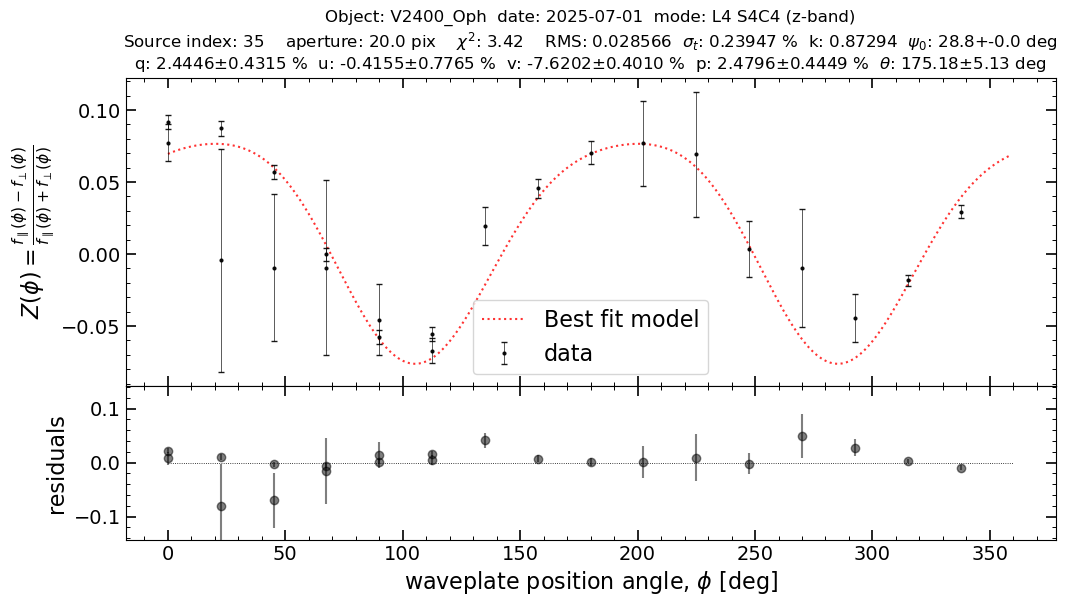

In [24]:
source_index = target

pol_results = s4pipelib.get_polarimetry_results(polar_example,
                                                source_index=source_index,
                                                min_aperture=5,
                                                max_aperture=21,
                                                plot=True,
                                                verbose=True)

Below we print all variables names for the measurements available in the polar product

In [26]:
for key in pol_results.keys():
    print(key, ":", pol_results[key])

POLAR_PRODUCT : /media/fernando/KINGSTON/Doutorado/2025/reduced/20250701/sparc4acs4/20250701_s4c4_Gain2_1.0_Conventional_2_V2400_Oph_POLAR_L4_polar.fits
SOURCE_INDEX : 35
POLARIMETRY_SUCCESS : True
APERTURE_INDEX : 6
APERTURE_RADIUS : 20.0
NEXPS : 22
MAG : -12.004+-0.002
RA : 258.15141565117307
DEC : -24.24578487056358
FWHM : 7.676106130360626
X1 : 459.7159470604884
Y1 : 567.5807733557995
X2 : 478.98793114581304
Y2 : 532.2754043695523
WAVEPLATE_ANGLES : [  0.   22.5  45.   67.5  90.  112.5 135.  157.5 180.  202.5 225.  247.5
 270.  292.5 315.  337.5   0.   22.5  45.   67.5  90.  112.5]
ZI : [0.08+-0.01, -0.00+-0.08, -0.01+-0.05, -0.01+-0.06, -0.05+-0.02,
 -0.067+-0.009, 0.02+-0.01, 0.046+-0.007, 0.070+-0.008, 0.08+-0.03,
 0.07+-0.04, 0.00+-0.02, -0.01+-0.04, -0.04+-0.02, -0.018+-0.004,
 0.029+-0.005, 0.092+-0.005, 0.087+-0.005, 0.057+-0.005, -0.000+-0.004,
 -0.058+-0.005, -0.056+-0.005]
FO : [1050+-20, 170+-20, 270+-20, 210+-20, 480+-20, 1200+-20, 920+-20, 1780+-20,
 1560+-20, 470+-20,

And below we show a simple example how to get one of these measurements out. For instance, we're getting the total polarization and the polarization angle. 

In [28]:
p = pol_results["P"]*100
pa = pol_results["THETA"]
print("Polarization: {} %  Angle of polarization: {} deg".format(p,pa) )

Polarization: 2.5+-0.4 %  Angle of polarization: 175+-5 deg deg


Finally, we show below an example of a polarimetric time series product. 

In [30]:
polar_ts = fits.open(polar_time_series_example)
pd.DataFrame(polar_ts[1].data)

ValueError: Big-endian buffer not supported on little-endian compiler

ValueError: Big-endian buffer not supported on little-endian compiler

In [31]:
pd.DataFrame(polar_ts[1].data).columns

Index(['TIME', 'SRCINDEX', 'RA', 'DEC', 'X1', 'Y1', 'X2', 'Y2', 'FWHM', 'MAG',
       'EMAG', 'Q', 'EQ', 'U', 'EU', 'V', 'EV', 'P', 'EP', 'THETA', 'ETHETA',
       'K', 'EK', 'ZERO', 'EZERO', 'NOBS', 'NPAR', 'CHI2', 'RMS', 'TSIGMA'],
      dtype='object')

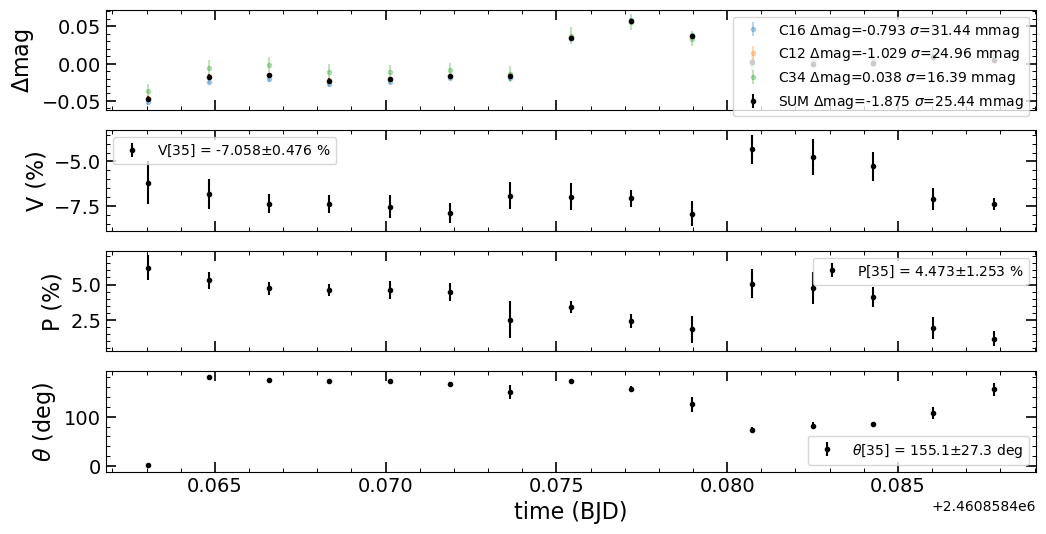

diffmag_C00000,diffmag_err_C00000,diffmag_C00001,diffmag_err_C00001,diffmag_C00002,diffmag_err_C00002,TIME,x1,y1,x2,y2,fwhm,mag,mag_err,magsum,magsum_err,diffmagsum,polarization_1,polarization_1_err,polarization_2,polarization_2_err
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
-0.05190725525114992,0.004150351829677496,-0.0462025396524659,0.003977511598442369,-0.03627128155226167,0.008520984479278458,2460858.463052186,459.7159470604884,567.5807733557995,478.98793114581304,532.2754043695523,7.372834176843748,-10.108905854178769,0.0037204303499028986,-12.03044216522282,0.008008020314442232,-0.04700219959734042,0.062091876236495744,0.008747696653663645,1.8936684863742541,4.029256956930697
-0.02401395058799949,0.003835103592998869,-0.016957272818611813,0.003669937859134994,-0.00533472309569305,0.01058240174784482,2460858.4648202746,460.9659470604884,569.3307733557995,480.23793114581304,534.0254043695523,7.372834176843748,-10.196116615659106,0.003420247739820991,-12.088622330214422,0.010250336892340783,-0.017971603108605905,0.053179370798330614,0.005997410081164598,179.7907100358993,3.22542229714933
-0.021204584979603425,0.003677136470723398,-0.015679361796745894,0.003517724678799098,-0.0013606124485150417,0.010184902784973892,2460858.466585481,461.2159470604884,570.8307733557995,480.48793114581304,535.5254043695523,7.387054759398074,-10.241197474964112,0.0032773451509991816,-12.131399129413031,0.009869396666625157,-0.015667543002209072,0.047266602301525185,0.00473569725476131,173.54096764435724,2.8654681083730678
-0.02785645711202278,0.0036011000747394576,-0.02228671334025023,0.0034471940880911665,-0.011052038584532298,0.009996888540826218,2460858.4683511388,459.2159470604884,571.8307733557995,478.48793114581304,536.5254043695523,7.4335644873327995,-10.249658030676471,0.003213182671902109,-12.147006885950427,0.00968582576128261,-0.022814743827245465,0.04610600164266487,0.004454320459543436,173.22374772181192,2.7630581834070105
-0.024344861273108975,0.0033578395732213303,-0.02076098381315994,0.0032130150436049092,-0.011752678560904783,0.009403271192413857,2460858.470118353,457.9659470604884,572.8307733557995,477.23793114581304,537.5254043695523,7.491552588587025,-10.3130177622091,0.002994000877318852,-12.208483010955051,0.009117452364989072,-0.020931137299241342,0.04599141060674403,0.006216843326078073,171.53416029227597,3.86597664172885
-0.01893953037392393,0.0034407122833530956,-0.01683623326725936,0.0032917161724127656,-0.008725683556797037,0.009671345381850471,2460858.471883618,455.9659470604884,573.5807733557995,475.23793114581304,538.2754043695523,7.588063875734005,-10.284310170967121,0.0030654908528348,-12.175455181027692,0.009381743727321673,-0.01661089861386067,0.044726147698538075,0.006659304961237449,166.38498183031933,4.2582724355135175
-0.019121825742960397,0.0037557271658516136,-0.015906765906697373,0.003592739989952514,-0.014033231867278673,0.010474247680489776,2460858.4736492527,458.9659470604884,573.8307733557995,478.23793114581304,538.5254043695523,7.600246481503312,-10.192668260883572,0.0033463110357914386,-12.084361055483699,0.010155281335698511,-0.01715868315341673,0.025004228118681835,0.012980265594963394,149.97709590738572,14.846912860252843
0.033831707168587855,0.002907469862284755,0.035468547866782885,0.00277108727656712,0.03763860851404033,0.010802338521317864,2460858.475415917,459.7159470604884,576.0807733557995,478.98793114581304,540.7754043695523,7.676106130360626,-10.483758606890767,0.002562524740171755,-12.323441419580334,0.010635940207222734,0.03485129875714321,0.03381351843284117,0.004218949043673748,172.40112876055497,3.568452744387494
0.05778345998507284,0.002682349246594822,0.057683638222568945,0.002551353190022901,0.05530668011725126,0.010946726785322684,2460858.47718143,461.4659470604884,576.3307733557995,480.73793114581304,541.0254043695523,7.676106130360626,-10.57945843510

In [32]:
s4plt.plot_polar_time_series(polar_time_series_example, 
                             target=target, 
                             comps=comps, 
                             plot_total_polarization=True, 
                             plot_polarization_angle=True)